In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv("../data/store_sales.csv")

# Vista general
print(df.shape)
print(df.dtypes)
print(df.head())
print(df.describe())
print(df.isnull().sum())

(7300, 5)
date           str
store        int64
sales      float64
promo        int64
holiday      int64
dtype: object
         date  store   sales  promo  holiday
0  2022-01-01      1  184.78      0        0
1  2022-01-02      1  192.62      0        0
2  2022-01-03      1  212.68      0        0
3  2022-01-04      1  249.58      1        0
4  2022-01-05      1  223.50      0        0
             store        sales        promo      holiday
count  7300.000000  7300.000000  7300.000000  7300.000000
mean      5.500000   228.434571     0.202192     0.104110
std       2.872478    26.625636     0.401662     0.305424
min       1.000000   160.710000     0.000000     0.000000
25%       3.000000   209.217500     0.000000     0.000000
50%       5.500000   226.795000     0.000000     0.000000
75%       8.000000   245.590000     0.000000     0.000000
max      10.000000   340.730000     1.000000     1.000000
date       0
store      0
sales      0
promo      0
holiday    0
dtype: int64


In [3]:
# Ver las primeras filas
df.head(10)

,date,store,sales,promo,holiday
0,2022-01-01,1,184.78,0,0
1,2022-01-02,1,192.62,0,0
2,2022-01-03,1,212.68,0,0
3,2022-01-04,1,249.58,1,0
4,2022-01-05,1,223.50,0,0
5,2022-01-06,1,221.79,0,0
6,2022-01-07,1,200.43,0,0
7,2022-01-08,1,213.47,1,0
8,2022-01-09,1,222.44,1,0
9,2022-01-10,1,203.10,0,0


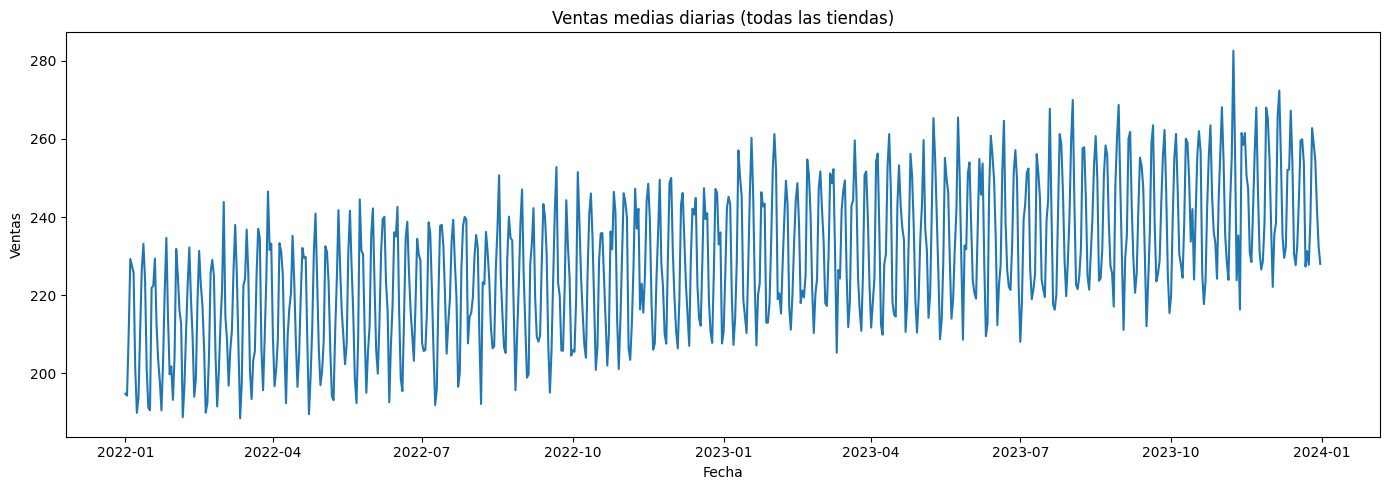

In [4]:
df["date"] = pd.to_datetime(df["date"])

# Ventas medias diarias de todas las tiendas
ventas_diarias = df.groupby("date")["sales"].mean()

plt.figure(figsize=(14, 5))
plt.plot(ventas_diarias)
plt.title("Ventas medias diarias (todas las tiendas)")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.tight_layout()
plt.show()

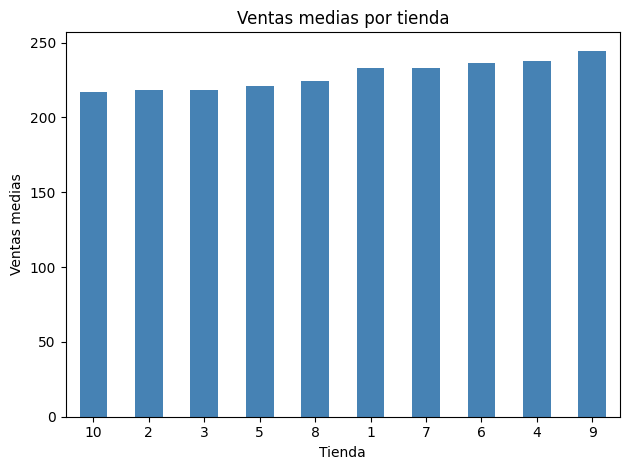

In [5]:
# Ventas medias por tienda
ventas_tienda = df.groupby("store")["sales"].mean().sort_values()

ventas_tienda.plot(kind="bar", color="steelblue")
plt.title("Ventas medias por tienda")
plt.xlabel("Tienda")
plt.ylabel("Ventas medias")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

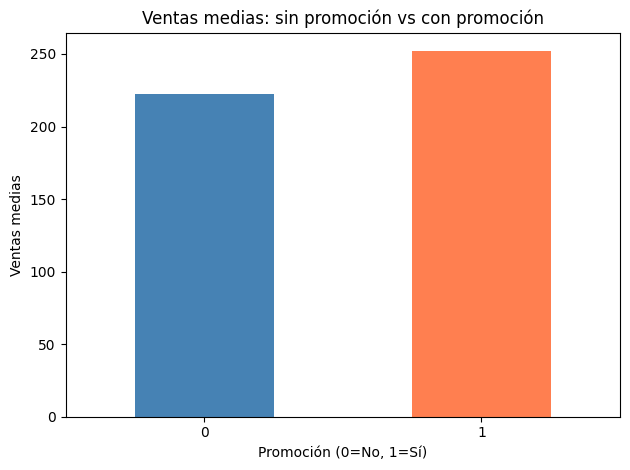

In [6]:
# Impacto de promociones en las ventas
df.groupby("promo")["sales"].mean().plot(kind="bar", color=["steelblue", "coral"])
plt.title("Ventas medias: sin promoción vs con promoción")
plt.xlabel("Promoción (0=No, 1=Sí)")
plt.ylabel("Ventas medias")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

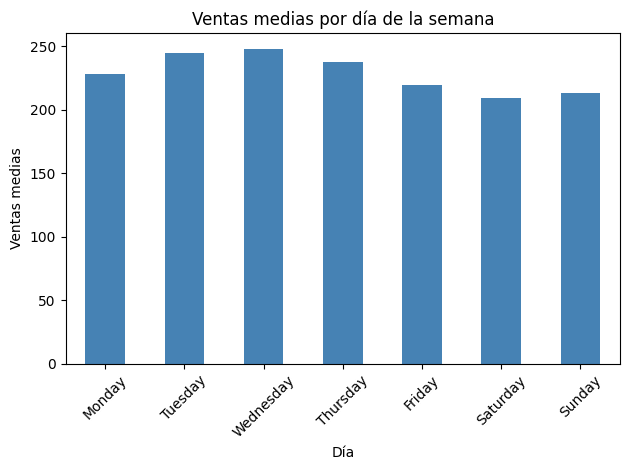

In [7]:
# Ventas medias por día de la semana
df["day_of_week"] = df["date"].dt.day_name()
orden = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

df.groupby("day_of_week")["sales"].mean().reindex(orden).plot(kind="bar", color="steelblue")
plt.title("Ventas medias por día de la semana")
plt.xlabel("Día")
plt.ylabel("Ventas medias")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

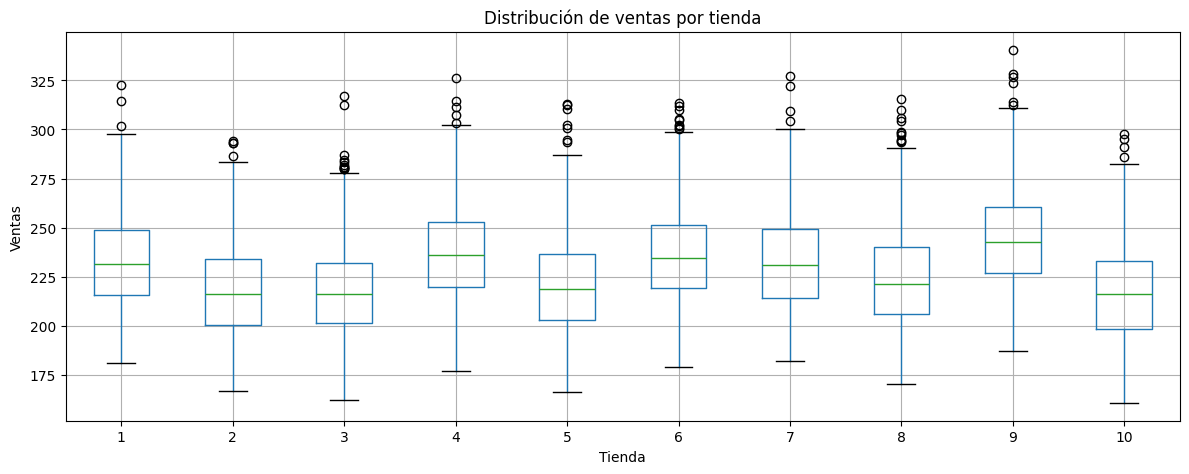

In [8]:
# Distribución de ventas por tienda - detección de outliers
df.boxplot(column="sales", by="store", figsize=(12, 5))
plt.title("Distribución de ventas por tienda")
plt.suptitle("")
plt.xlabel("Tienda")
plt.ylabel("Ventas")
plt.tight_layout()
plt.show()

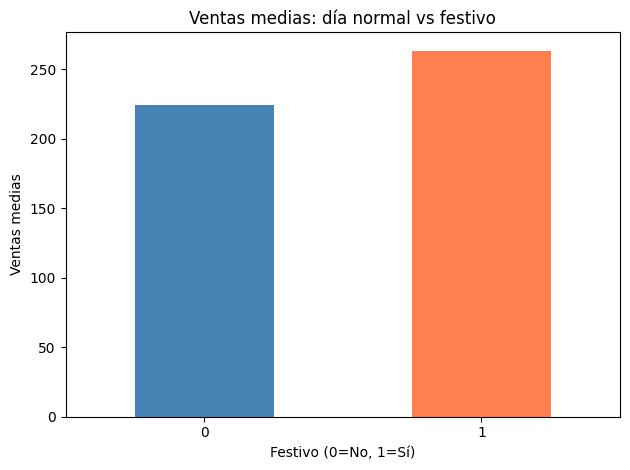

In [9]:
# Impacto de festivos en las ventas
df.groupby("holiday")["sales"].mean().plot(kind="bar", color=["steelblue", "coral"])
plt.title("Ventas medias: día normal vs festivo")
plt.xlabel("Festivo (0=No, 1=Sí)")
plt.ylabel("Ventas medias")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

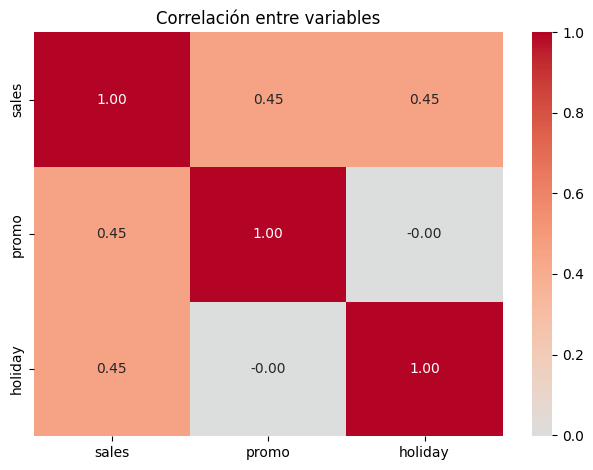

In [10]:
# Correlación entre variables numéricas
corr = df[["sales", "promo", "holiday"]].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación entre variables")
plt.tight_layout()
plt.show()

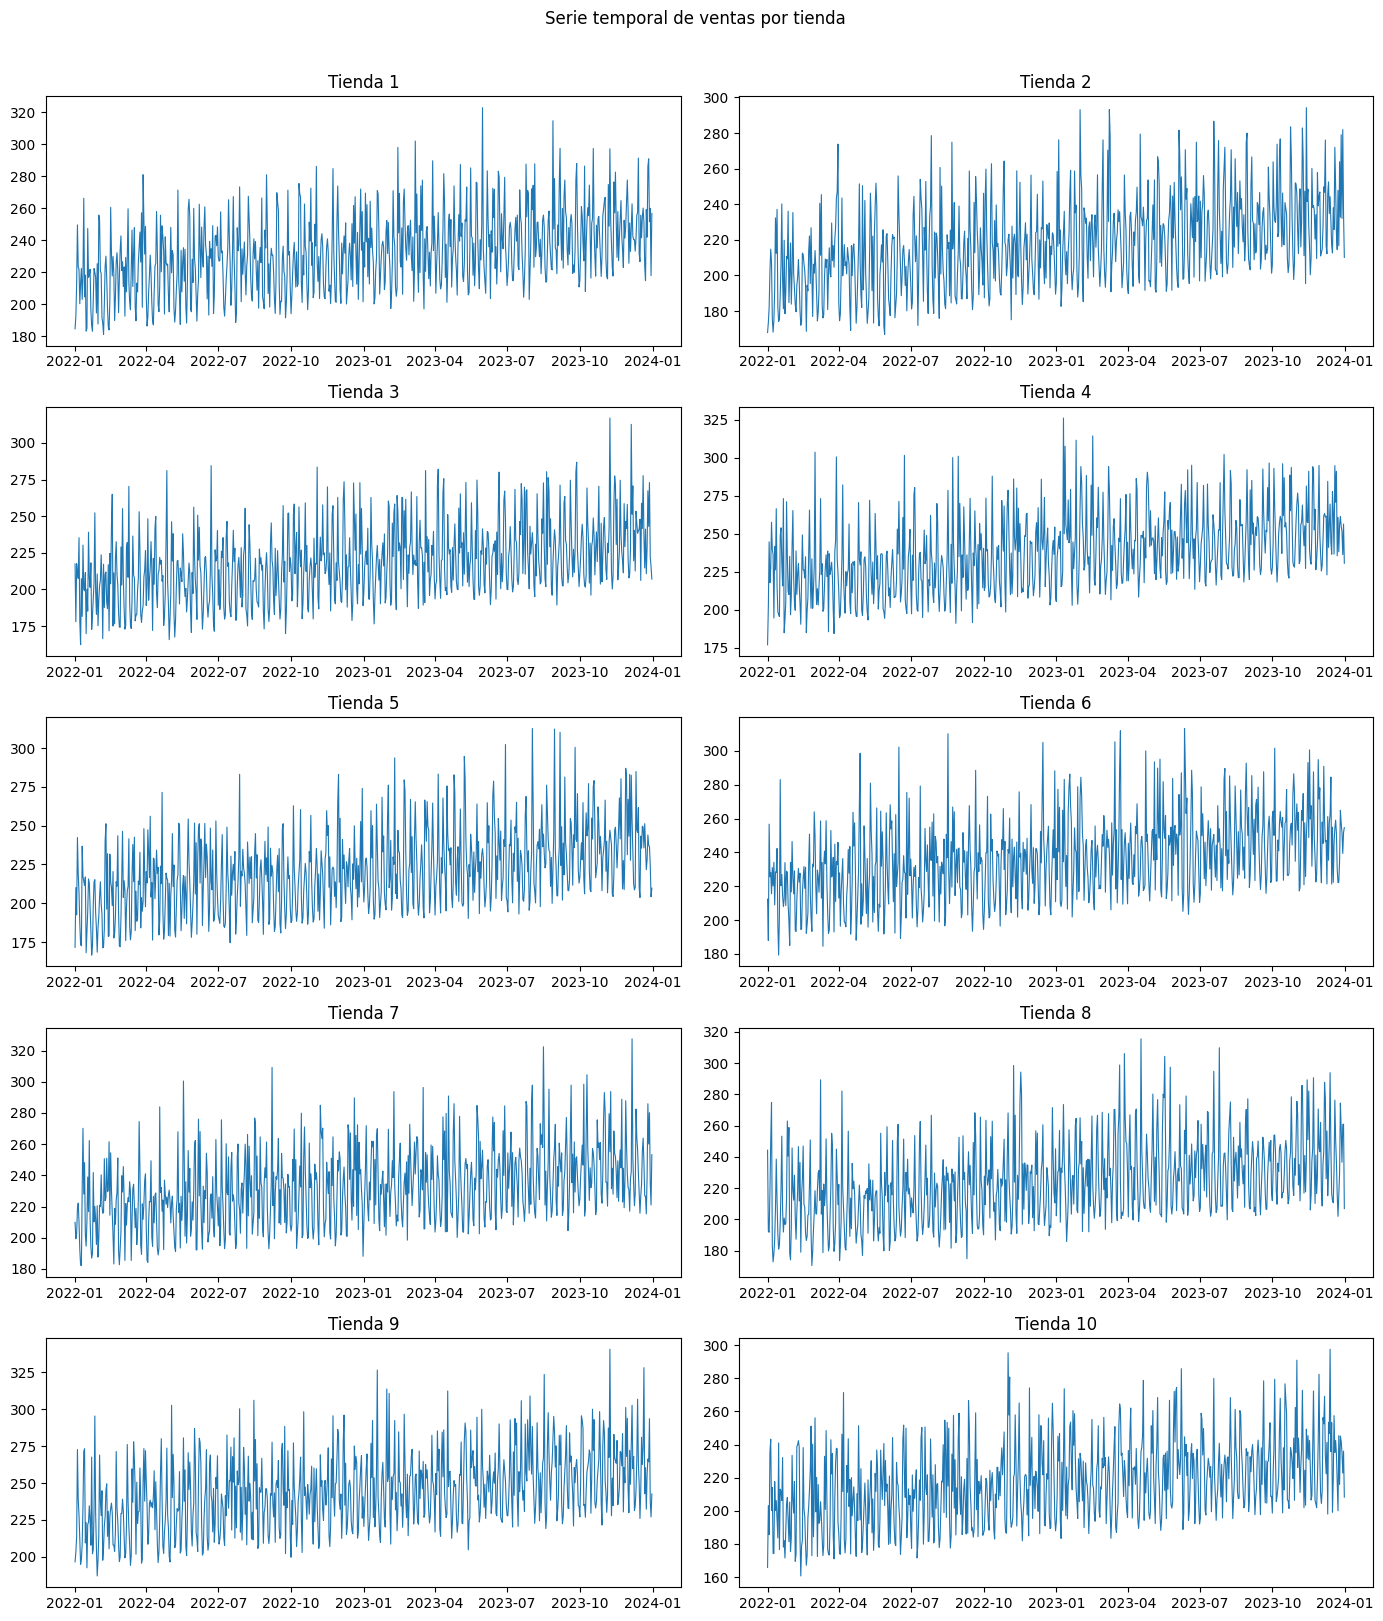

In [11]:
# Serie temporal por tienda individual
fig, axes = plt.subplots(5, 2, figsize=(14, 16))
axes = axes.flatten()

for i, store in enumerate(sorted(df["store"].unique())):
    datos = df[df["store"] == store].set_index("date")["sales"]
    axes[i].plot(datos, linewidth=0.8)
    axes[i].set_title(f"Tienda {store}")
    axes[i].set_xlabel("")

plt.suptitle("Serie temporal de ventas por tienda", y=1.01)
plt.tight_layout()
plt.show()

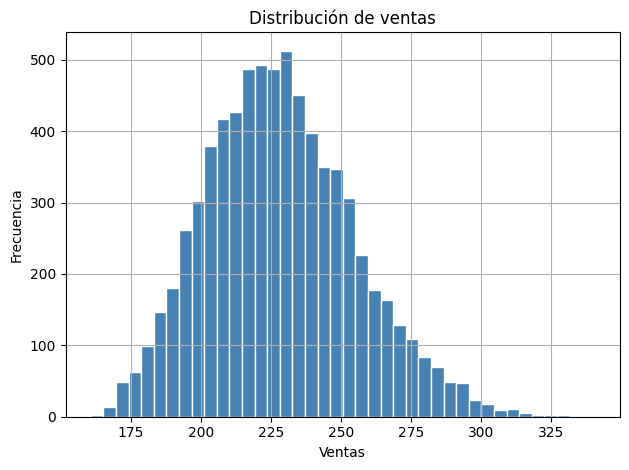

In [12]:
# Distribución de ventas - histograma
df["sales"].hist(bins=40, color="steelblue", edgecolor="white")
plt.title("Distribución de ventas")
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

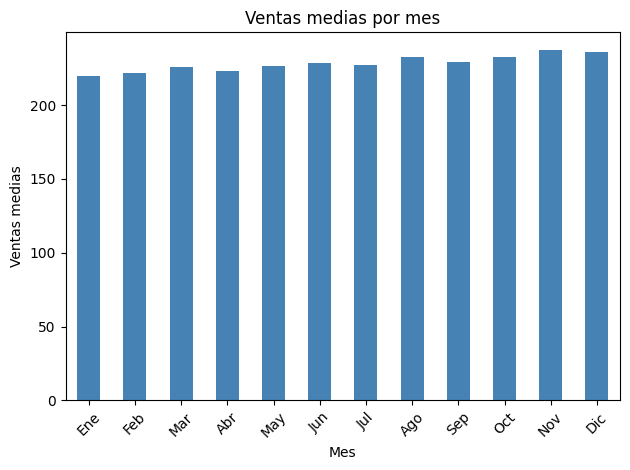

In [13]:
# Ventas medias por mes
df["month"] = df["date"].dt.month
meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

df.groupby("month")["sales"].mean().plot(kind="bar", color="steelblue")
plt.title("Ventas medias por mes")
plt.xlabel("Mes")
plt.ylabel("Ventas medias")
plt.xticks(ticks=range(12), labels=meses, rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
## Diccionario de Datos

| Campo   | Tipo    | Rango / Valores      | Descripción                              |
|---------|---------|----------------------|------------------------------------------|
| date    | DATE    | 2022-01-01 a 2023-12-31 | Fecha de la venta                     |
| store   | INTEGER | 1 – 10               | Identificador de tienda (SKU)            |
| sales   | FLOAT   | 160.71 – 340.73      | Unidades vendidas en el día              |
| promo   | BOOLEAN | 0 / 1                | Indica si hay promoción activa (20% días)|
| holiday | BOOLEAN | 0 / 1                | Indica si es día festivo (10% días)      |

**Reglas de negocio:**
- No existen combinaciones duplicadas de (date, store)
- Todos los SKUs tienen datos diarios continuos sin gaps
- promo y holiday son independientes entre sí (correlación ~0)
- Los outliers (sales > 300) se mantienen por corresponder a eventos reales

In [ ]:
## Conclusiones del EDA

**Dataset**
- 7.300 filas, 10 tiendas, rango 2022-2023, 0 nulos, 0 duplicados

**Distribución**
- Ventas entre 160 y 340, media ~228, distribución aproximadamente normal
  con cola derecha leve (outliers por eventos especiales)

**Tendencia y estacionalidad**
- Tendencia creciente clara a lo largo del período
- Estacionalidad semanal muy marcada: pico martes-miércoles, mínimo sábado
- Estacionalidad mensual prácticamente inexistente

**Variables externas**
- Promociones: +13% en ventas (de ~222 a ~252)
- Festivos: +18% en ventas (de ~224 a ~264)
- Ambas variables tienen correlación 0.45 con ventas y son independientes entre sí

**Decisiones para el modelado**
- SKU piloto: Tienda 1 (todas homogéneas, referencia natural)
- Variables clave: promo, holiday, day_of_week
- Outliers: se mantienen (corresponden a eventos reales con valor predictivo)